# **Problem Statement**


---

#### **Business Context**  
Understanding customer personality and behavior is pivotal for businesses to enhance customer satisfaction and increase revenue. Segmentation based on a customer's personality, demographics, and purchasing behavior allows companies to create tailored marketing campaigns, improve customer retention, and optimize product offerings.  

A leading retail company with a rapidly growing customer base seeks to gain deeper insights into their customers' profiles. The company recognizes that understanding customer personalities, lifestyles, and purchasing habits can unlock significant opportunities for personalizing marketing strategies and creating loyalty programs. These insights can help address critical business challenges, such as improving the effectiveness of marketing campaigns, identifying high-value customer groups, and fostering long-term relationships with customers.  

With the competition intensifying in the retail space, moving away from generic strategies to more targeted and personalized approaches is essential for sustaining a competitive edge.  

---

#### **Objective**  
In an effort to optimize marketing efficiency and enhance customer experience, the company has embarked on a mission to identify distinct customer segments. By understanding the characteristics, preferences, and behaviors of each group, the company aims to:  
1. Develop personalized marketing campaigns to increase conversion rates.  
2. Create effective retention strategies for high-value customers.  
3. Optimize resource allocation, such as inventory management, pricing strategies, and store layouts.  

As a data scientist tasked with this project, your responsibility is to analyze the given customer data, apply machine learning techniques to segment the customer base, and provide actionable insights into the characteristics of each segment.  

---

#### **Data Dictionary**  
The dataset includes historical data on customer demographics, personality traits, and purchasing behaviors. Key attributes are:  

1. **Customer Information**  
   - **ID:** Unique identifier for each customer.  
   - **Year_Birth:** Customer's year of birth.  
   - **Education:** Education level of the customer.  
   - **Marital_Status:** Marital status of the customer.  
   - **Income:** Yearly household income (in dollars).  
   - **Kidhome:** Number of children in the household.  
   - **Teenhome:** Number of teenagers in the household.  
   - **Dt_Customer:** Date when the customer enrolled with the company.  
   - **Recency:** Number of days since the customer’s last purchase.  
   - **Complain:** Whether the customer complained in the last 2 years (1 for yes, 0 for no).  

2. **Spending Information (Last 2 Years)**  
   - **MntWines:** Amount spent on wine.  
   - **MntFruits:** Amount spent on fruits.  
   - **MntMeatProducts:** Amount spent on meat.  
   - **MntFishProducts:** Amount spent on fish.  
   - **MntSweetProducts:** Amount spent on sweets.  
   - **MntGoldProds:** Amount spent on gold products.  

3. **Purchase and Campaign Interaction**  
   - **NumDealsPurchases:** Number of purchases made using a discount.  
   - **AcceptedCmp1:** Response to the 1st campaign (1 for yes, 0 for no).  
   - **AcceptedCmp2:** Response to the 2nd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp3:** Response to the 3rd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp4:** Response to the 4th campaign (1 for yes, 0 for no).  
   - **AcceptedCmp5:** Response to the 5th campaign (1 for yes, 0 for no).  
   - **Response:** Response to the last campaign (1 for yes, 0 for no).  

4. **Shopping Behavior**  
   - **NumWebPurchases:** Number of purchases made through the company’s website.  
   - **NumCatalogPurchases:** Number of purchases made using catalogs.  
   - **NumStorePurchases:** Number of purchases made directly in stores.  
   - **NumWebVisitsMonth:** Number of visits to the company’s website in the last month.  

# **Let's start coding!**

## **Importing necessary libraries**

In [19]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

## **Loading the data**

In [20]:
# uncomment and run the following line if using Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# loading data into a pandas dataframe
data = pd.read_csv("/content/Customer_Personality_Segmentation.csv", sep="\t")

## **Data Overview**

#### **Question 1**: What are the data types of all the columns?

In [22]:
# To obtain the data type for each column.
data.dtypes

,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
MntWines,int64


Observations: Out of the 29 columns in the dataset, 26 are numerical, with 25 columns of type int64 and 1 column of type float64, which is Income. The remaining 3 columns are categorical, stored as object types: Education, Marital_Status, and Dt_Customer.

#### **Question 2:** Check the statistical summary of the data. What is the average household income?

In [23]:
# The statistical summary of the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


##### **Observations:** Household Income has an average of 52,247.25, a median of 51,381.5 and a max of 666,666 which is very high and probably an outlier.

#### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [24]:
# checking for missing values
data.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [25]:
# checking the corresponding values in the other columns of the missing values
data[data['Income'].isnull()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,15-11-2013,11,5,5,6,0,2,1,1,1,0,2,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,20-02-2013,19,5,1,3,3,263,362,0,27,0,0,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,05-11-2013,80,81,11,50,3,2,39,1,1,3,4,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,01-01-2014,96,48,5,48,6,10,7,3,2,1,4,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,17-06-2013,57,11,3,22,2,2,6,2,2,0,3,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,14-09-2012,25,25,3,43,17,4,17,3,3,0,3,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,19-11-2012,4,230,42,192,49,37,53,12,7,2,8,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,27-05-2014,45,7,0,8,2,0,1,1,1,0,2,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,23-11-2013,87,445,37,359,98,28,18,1,2,4,8,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,11-07-2013,23,352,0,27,10,0,15,3,6,1,7,6,0,0,0,0,0,0,3,11,0


In [26]:
# make a copy of the original dataset

data_copy = data.copy()

In [27]:
# fill up the missing values with the median

data['Income'].fillna(data['Income'].median(), inplace=True)

##### **Observations:** The 'Income' column contains 24 missing values. These rows were not dropped, as the other columns in those rows contain important information crucial to data quality. The missing income values were replaced using the median, as the mean is skewed by outliers, such as extreme values like 666,666.

#### **Question 4**: Are there any duplicates in the data?

In [28]:
# check for duplicates in the data

data.duplicated().sum()

np.int64(0)

##### **Observations:** There are no dulplicates found in the data

## **Exploratory Data Analysis**

### Univariate Analysis

#### **Question 5:** Explore all the variables and provide observations on their distributions. (histograms and boxplots)

Year_Birth
Skew : -0.35


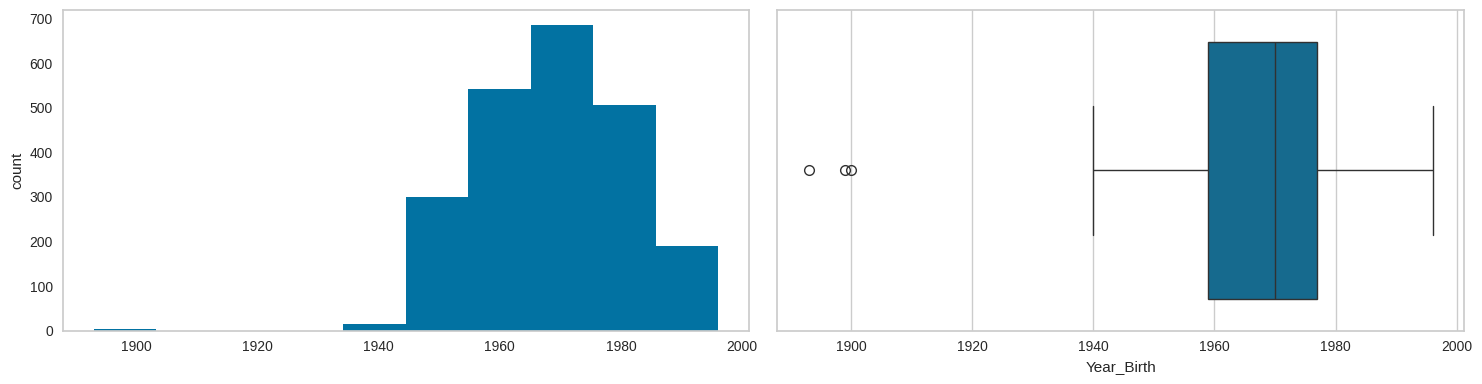

Income
Skew : 6.8


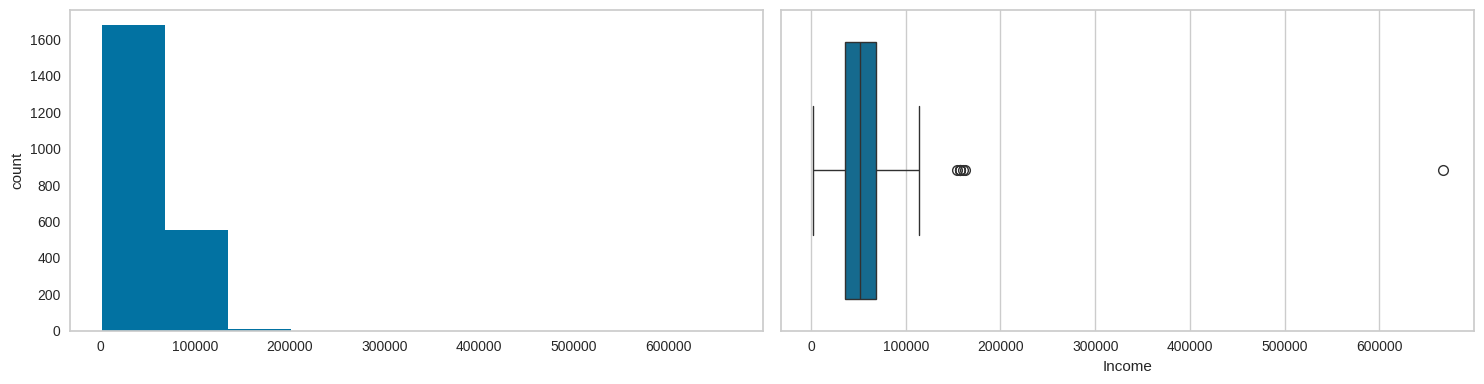

Kidhome
Skew : 0.64


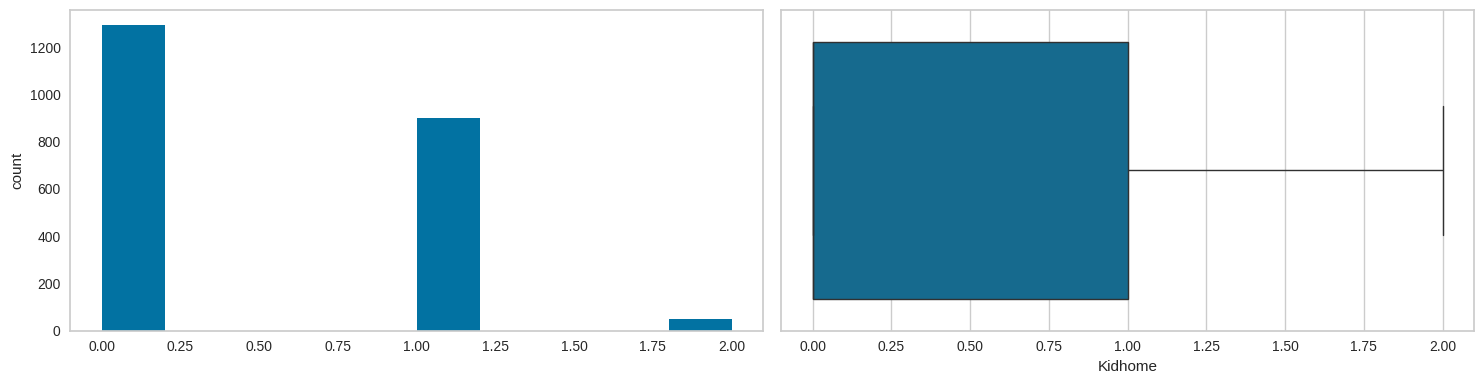

Teenhome
Skew : 0.41


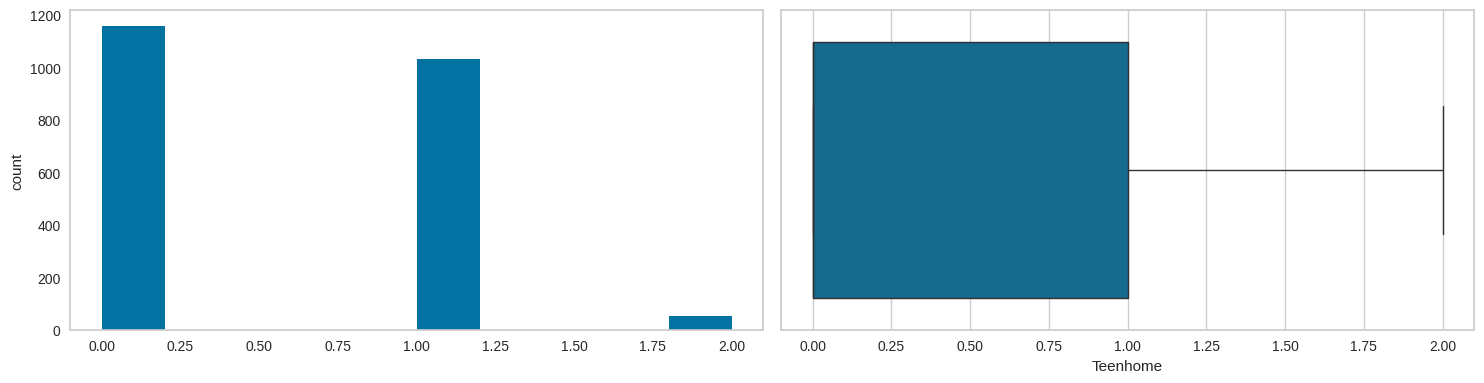

Recency
Skew : -0.0


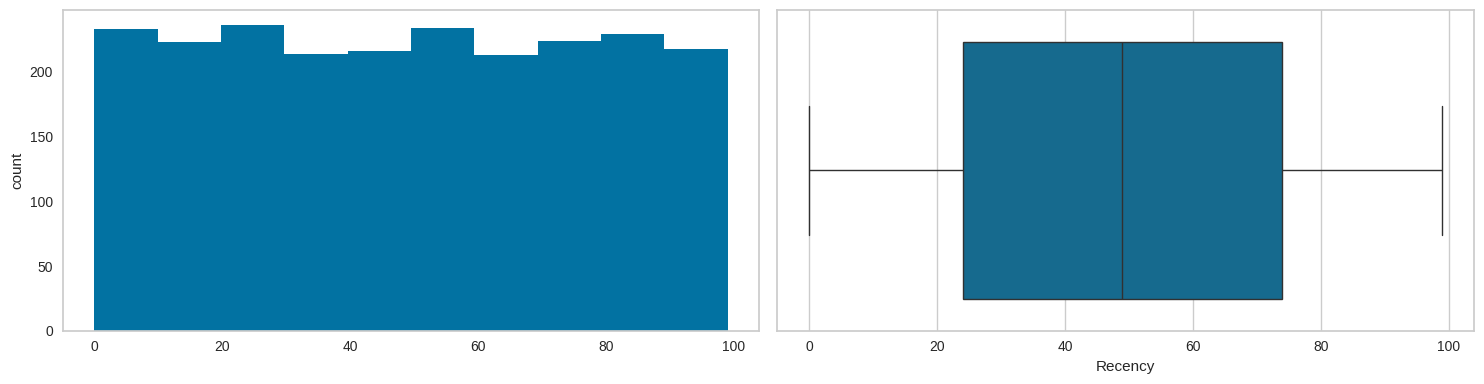

MntWines
Skew : 1.18


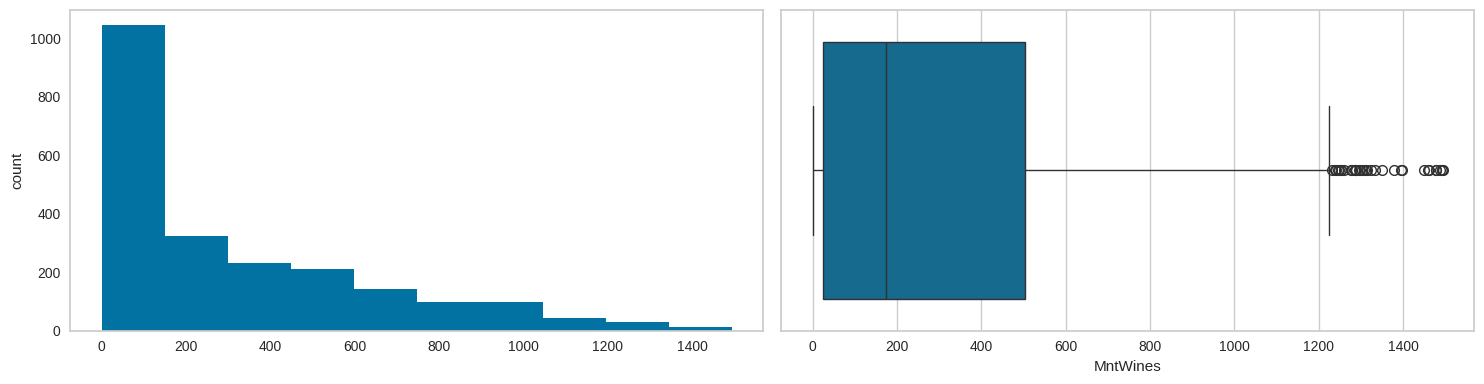

MntFruits
Skew : 2.1


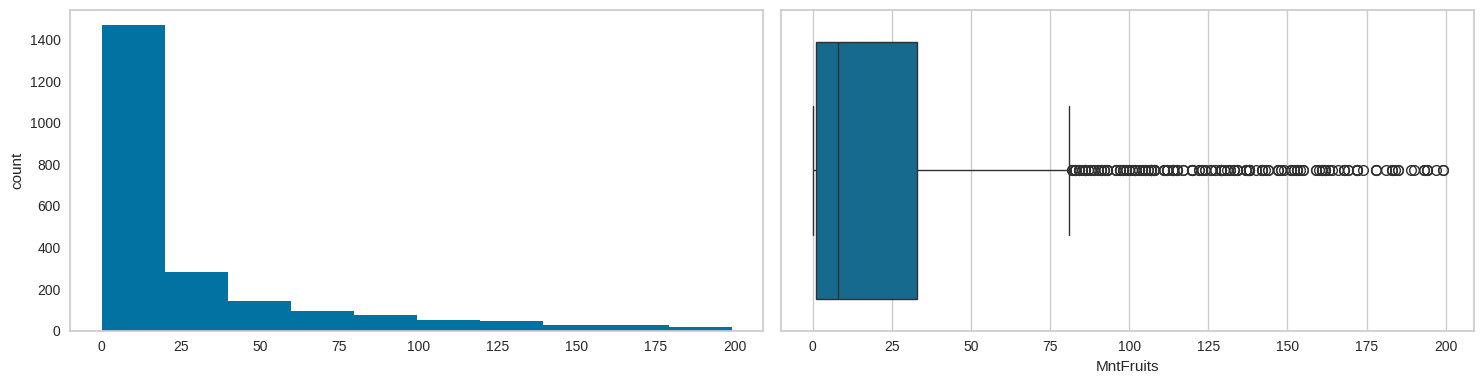

MntMeatProducts
Skew : 2.08


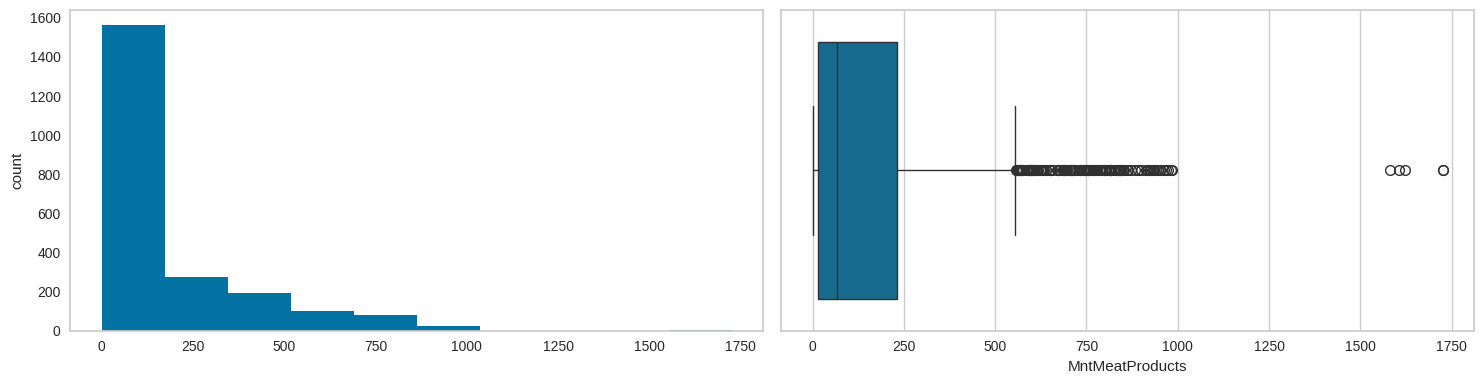

MntFishProducts
Skew : 1.92


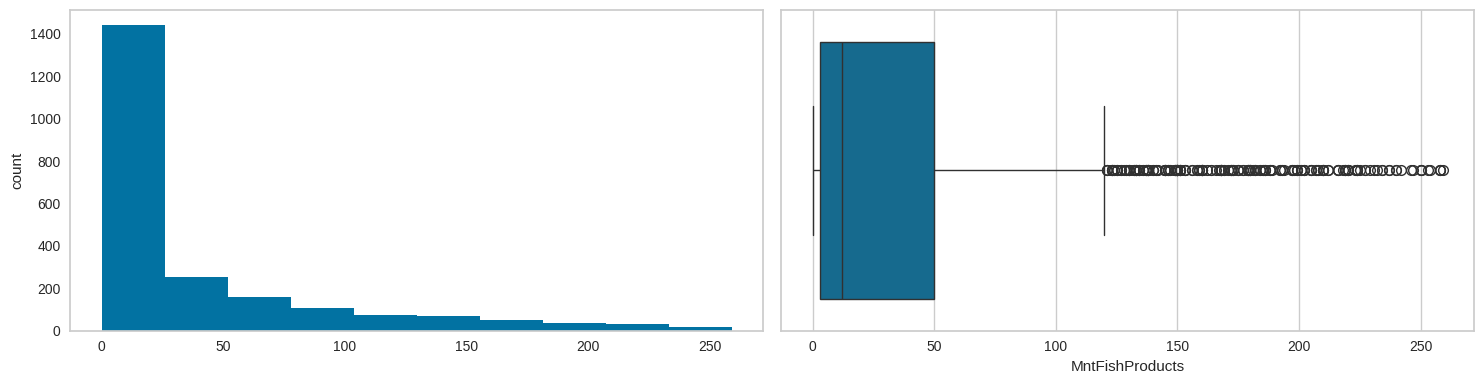

MntSweetProducts
Skew : 2.14


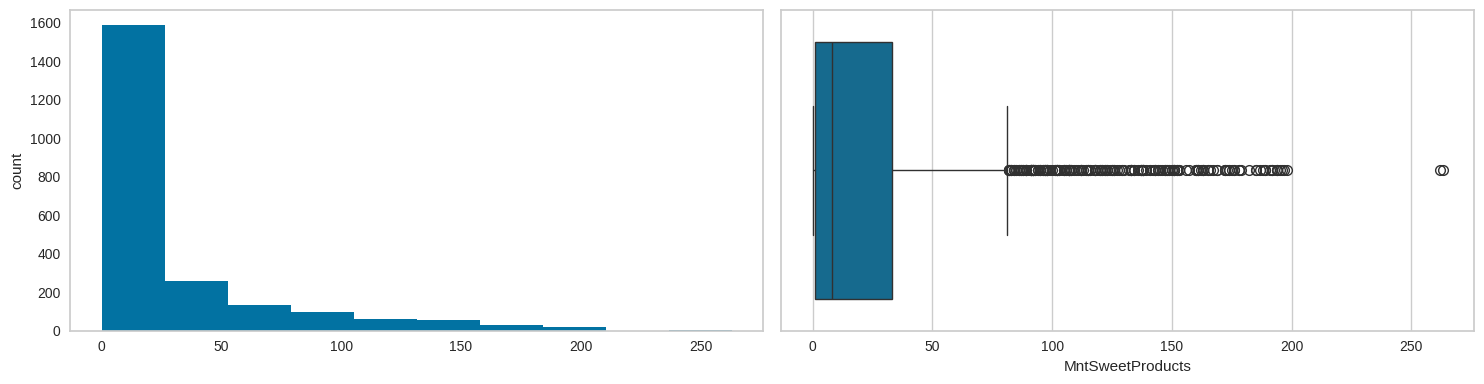

MntGoldProds
Skew : 1.89


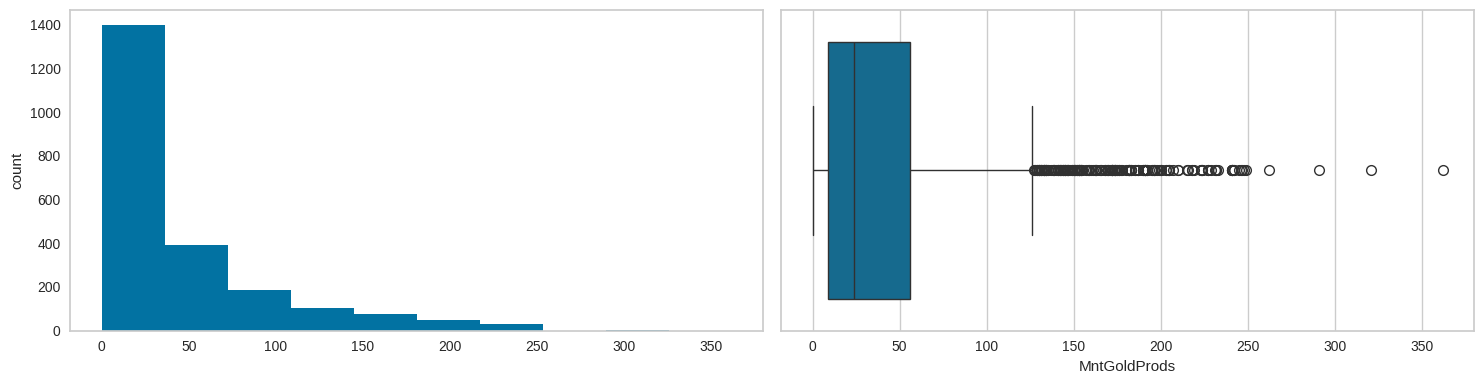

NumDealsPurchases
Skew : 2.42


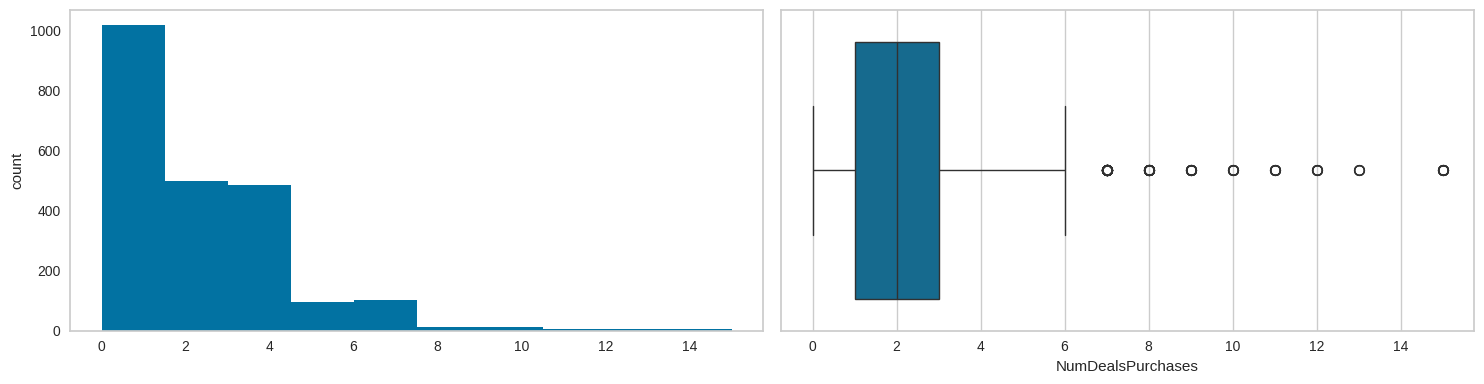

NumWebPurchases
Skew : 1.38


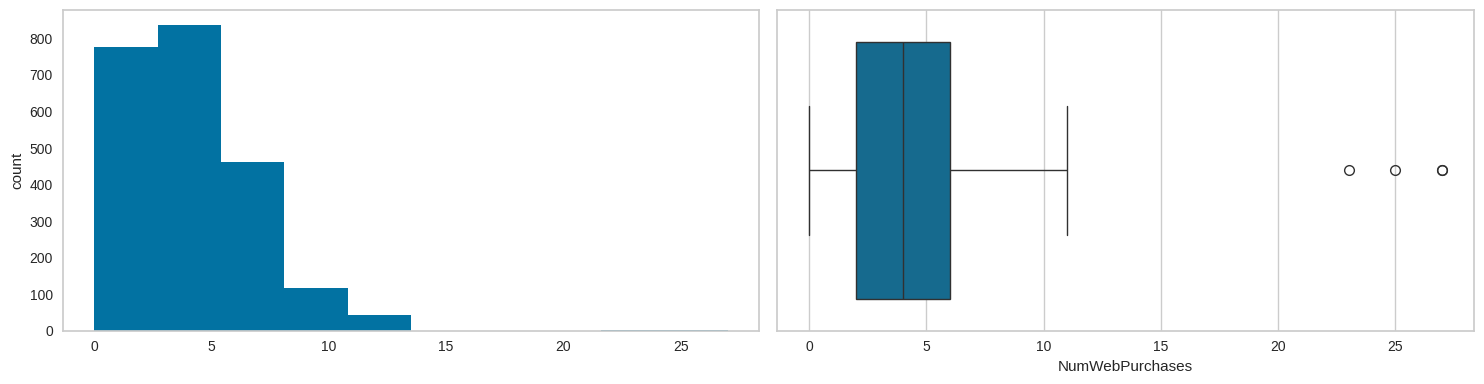

NumCatalogPurchases
Skew : 1.88


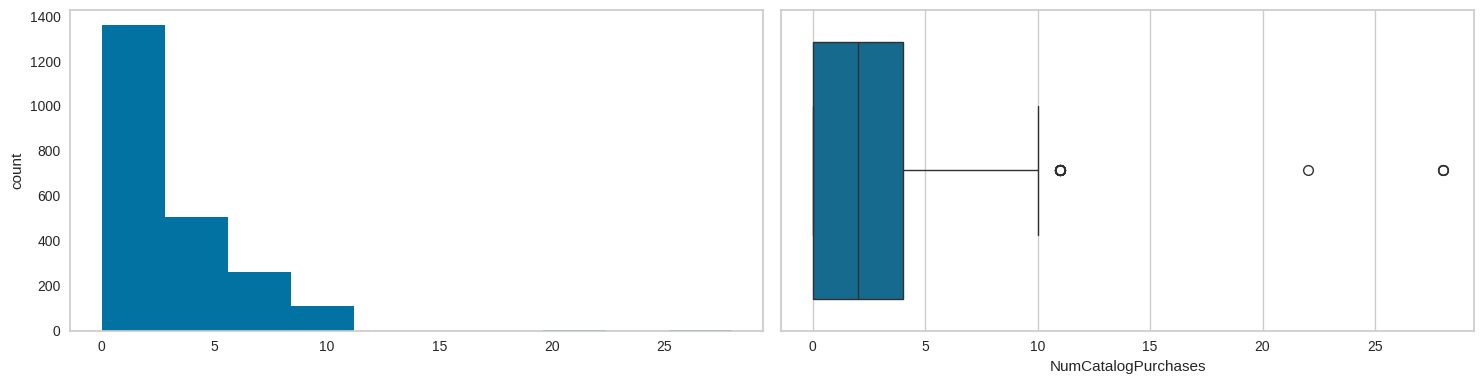

NumStorePurchases
Skew : 0.7


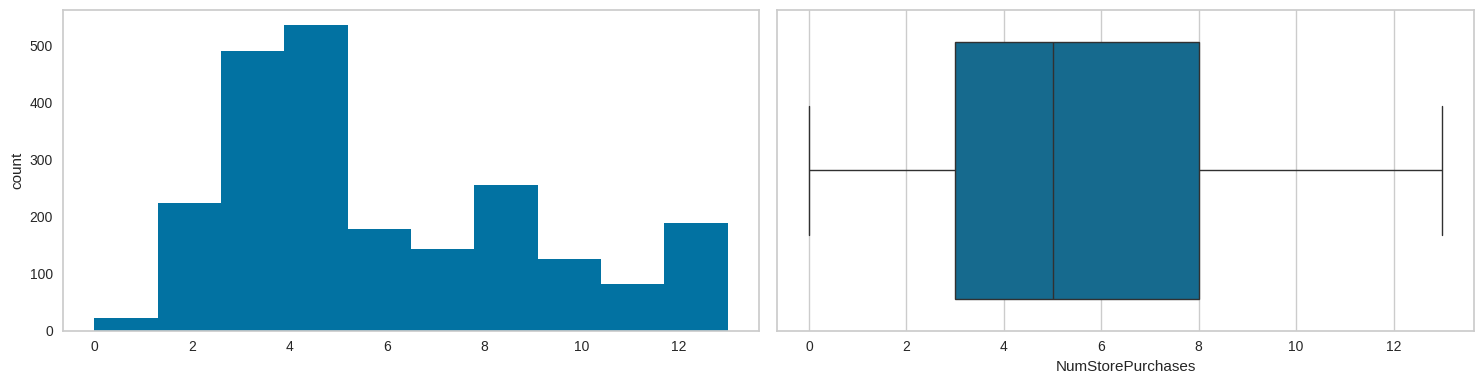

NumWebVisitsMonth
Skew : 0.21


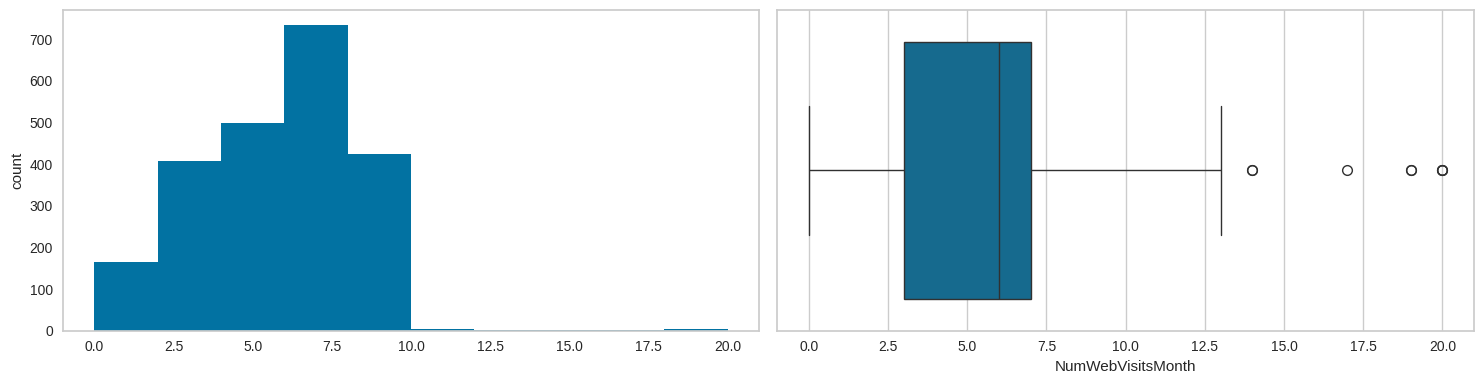

Complain
Skew : 10.19


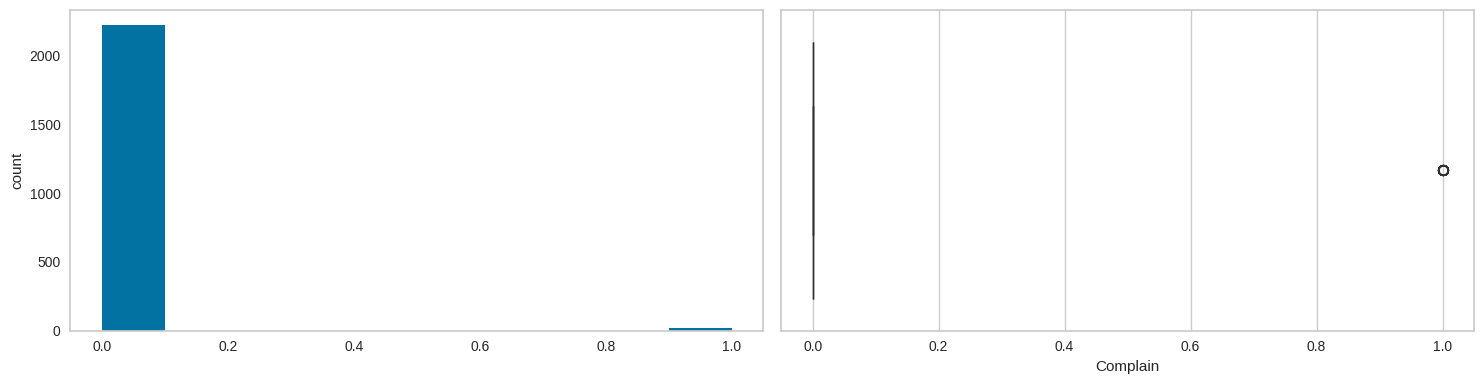

In [29]:
# drop the columns that has no analytical value the identifier, categorical columns and the constant columns
data = data.drop(['ID', 'Education', 'Marital_Status', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue', 'AcceptedCmp1',
                  'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response'], axis=1)


# plot the histogram and boxplot
for col in data:
    print(col)
    print('Skew :',round(data[col].skew(),2))
    plt.figure(figsize=(15,4))
    plt.subplot(1,2,1)
    data[col].hist(bins=10, grid=False)
    plt.ylabel('count')
    plt.subplot(1,2,2)
    sns.boxplot(x=data[col])
    plt.tight_layout()
    plt.show()

##### **Observations:**


*   Most of the customers are born between 1960 - 1980 and it has a few outliers which could be as a result of entry error due to extreme dates inputed.

*   The income distribution is highly right skewed and most of the customers earn below 100,000 with an outlier of 666,666.

*   The kid and teen distribution are discrete; most of the homes have no kids and no teens, some have one kid and teen and a few have 2 kids and 2 teens. These distributoons have no outlier.

*   Renecy is uniformly distributed, which means that the customers' purchase pattern is not clustered to a particular period.

*   The amount spent on each of the products have highly right skewed distribution. Which shows that customers spend little on each product. And the outliers show that a few customers spend heavily on the products.









### Bivariate Analysis

#### **Question 6:** Perform multivariate analysis to explore the relationsips between the variables.

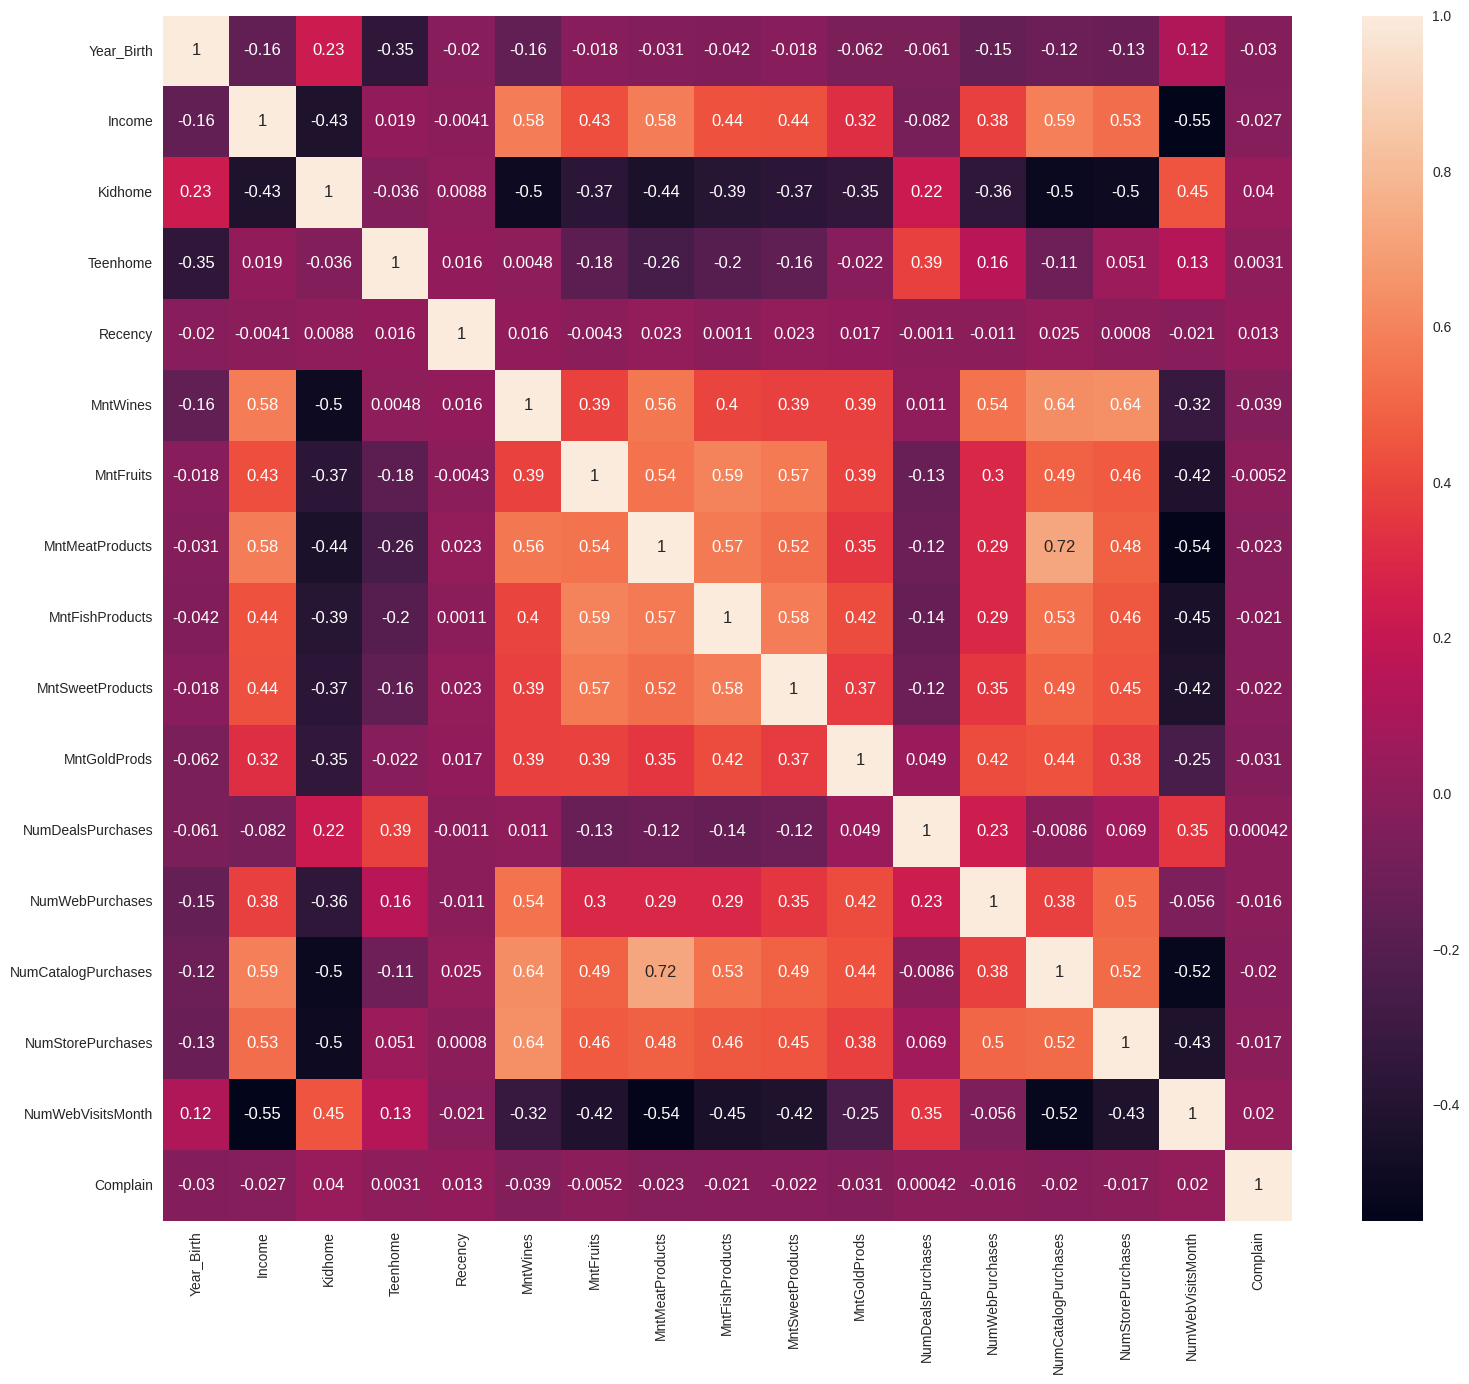

In [30]:
# heat map distribution to explore the relationships between the variables

plt.figure(figsize=(16,14))
sns.heatmap(data.corr(), annot=True)
plt.tight_layout()
plt.show()

##### **Observations:**

*   The spending columns which includes MntWines,MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds are positively correlated with income; which means the higher the income, the higher customers spend on these products.

*   Kidhome and Teenhome have a negative correlation with the spending variables which means that the higher the number of kids and teens, the lesser the amount spent to purchase products.

*   NumWebVisitsMonth is negatively correlated with the spending variables, high web visits and low purchases made.







## **K-means Clustering**

#### **Question 7** : Select the appropriate number of clusters using the elbow Plot. What do you think is the appropriate number of clusters?

In [31]:
# scale the data
scaler=StandardScaler()
data_scaled=pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

data_scaled.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain
0,-0.985345,0.235696,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,0.843207,0.349414,1.409304,2.510890,-0.550785,0.693904,-0.097282
1,-1.235733,-0.235454,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,-0.729006,-0.168236,-1.110409,-0.568720,-1.166125,-0.130463,-0.097282
2,-0.317643,0.773999,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,-0.038766,-0.685887,1.409304,-0.226541,1.295237,-0.542647,-0.097282
3,1.268149,-1.022355,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,-0.748179,-0.168236,-0.750450,-0.910898,-0.550785,0.281720,-0.097282
4,1.017761,0.241888,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,-0.556446,1.384715,0.329427,0.115638,0.064556,-0.130463,-0.097282


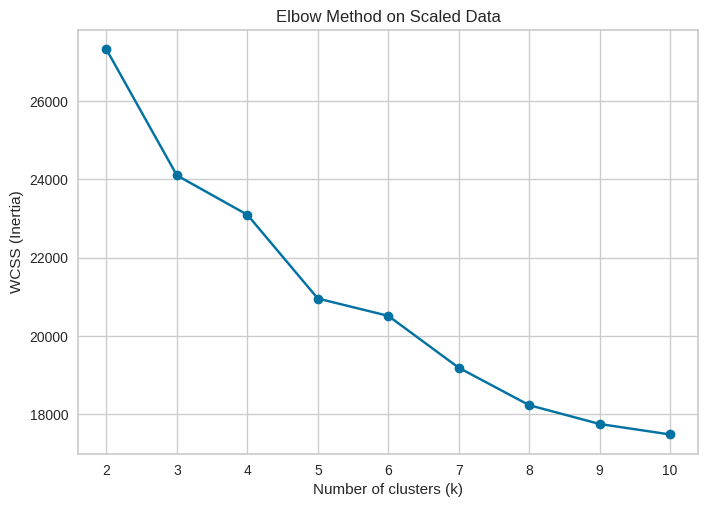

In [32]:
# find the within cluster sum of squares and run the k-means
wcss = []
# assign K a range of 2 to 10
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

# Plot
plt.plot(K, wcss, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method on Scaled Data')
plt.show()

##### **Observations:**
The break in the drop in the elbow curve around k = 5 indicates that the dataset can be effectively segmented into five distinct clusters.

#### **Question 8** : finalize appropriate number of clusters by checking the silhoutte score as well. Is the answer different from the elbow plot?

Silhouette score for k=2: 0.29547840739533776
Silhouette score for k=3: 0.22792558822408715
Silhouette score for k=4: 0.21226368500184617
Silhouette score for k=5: 0.2221881757062909
Silhouette score for k=6: 0.21405722249749795
Silhouette score for k=7: 0.1554644715662751
Silhouette score for k=8: 0.16238500514369875
Silhouette score for k=9: 0.15860130318002424
Silhouette score for k=10: 0.16050877118004075


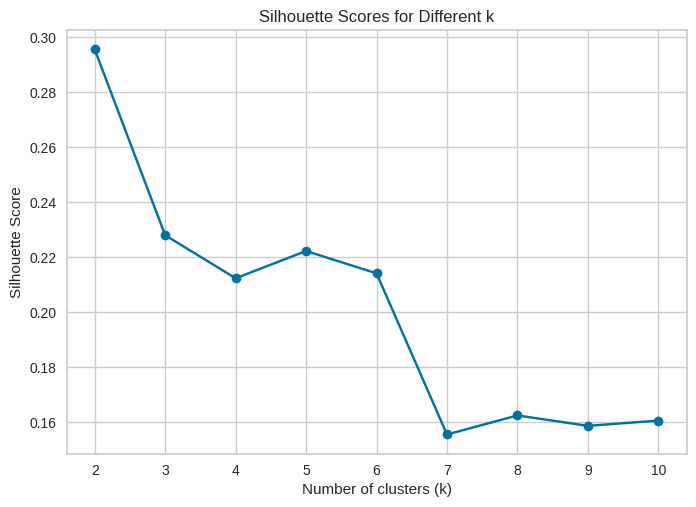

In [33]:
# Silhoutte score
silhouette_scores = []

# assign K a range of 2 to 10
K = list(range(2, 11))

# create a loop over the number of clusters, fit the kmodel and compute the average score
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=1)
    labels = kmeans.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    silhouette_scores.append(score)
    print(f"Silhouette score for k={k}: {score}")

# plot silhoutte score
plt.plot(K, silhouette_scores, marker='o')
plt.title("Silhouette Scores for Different k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()


##### **Observations:** The silhouette score peaks at k = 2, indicating that the optimal number of clusters for this dataset is two.

#### **Question 9**: Do a final fit with the appropriate number of clusters. How much total time does it take for the model to fit the data?

In [34]:

# import time
import time

# Measure start time
start_time = time.time()


# fit the model to the standardized data using the final k; k=2
kmeans_final = KMeans(n_clusters=2, random_state=1, n_init=10)
kmeans_final.fit(data_scaled)

# Measure end time
end_time = time.time()

# Measure time taken
elapsed_time = end_time - start_time

print(f"Final KMeans fit completed with k={2}")
print(f"Total time taken: {elapsed_time:.4f} seconds")

Final KMeans fit completed with k=2
Total time taken: 0.0240 seconds


##### **Observations:** The total run time is small and shows that the KMeans is computationally efficient.

## **Cluster Profiling and Comparison**

#### **Question 10**: Perform cluster profiling using boxplots for the K-Means algorithm. Analyze key characteristics of each cluster and provide detailed observations.

<Figure size 500x400 with 0 Axes>

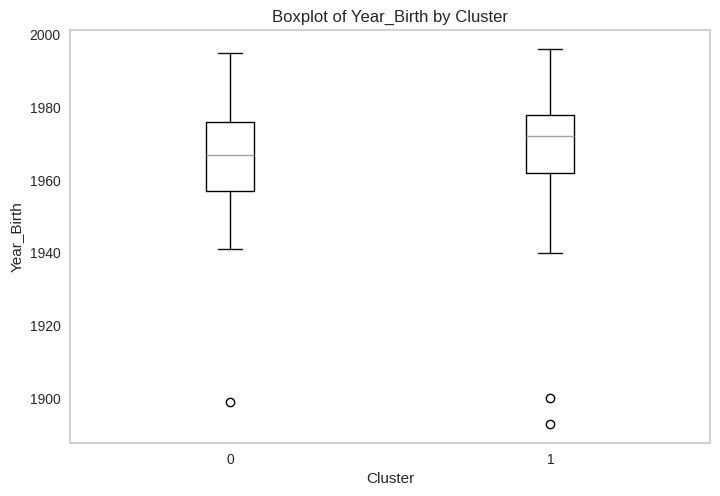

<Figure size 500x400 with 0 Axes>

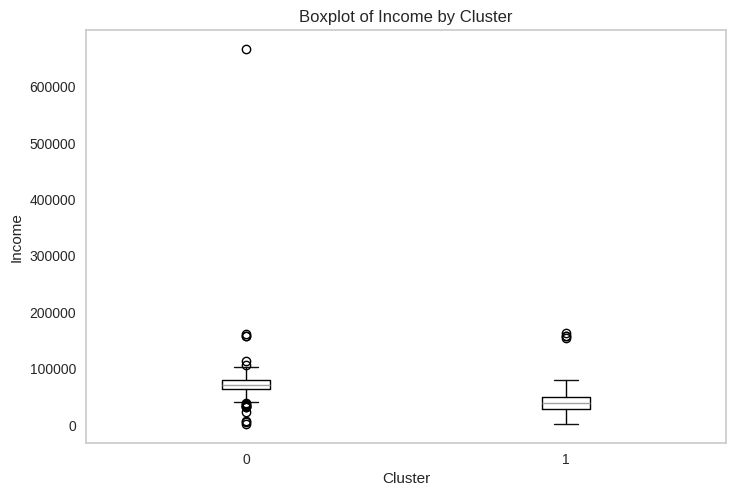

<Figure size 500x400 with 0 Axes>

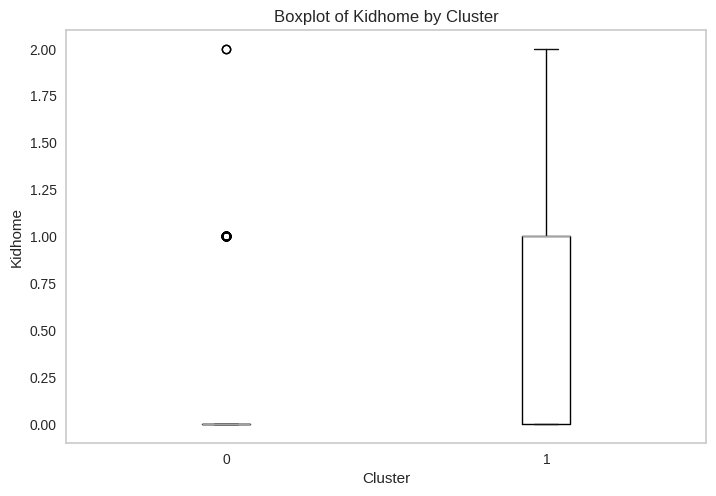

<Figure size 500x400 with 0 Axes>

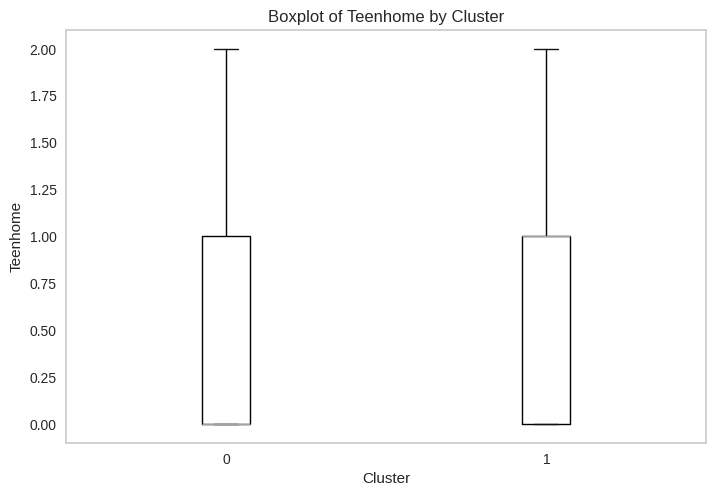

<Figure size 500x400 with 0 Axes>

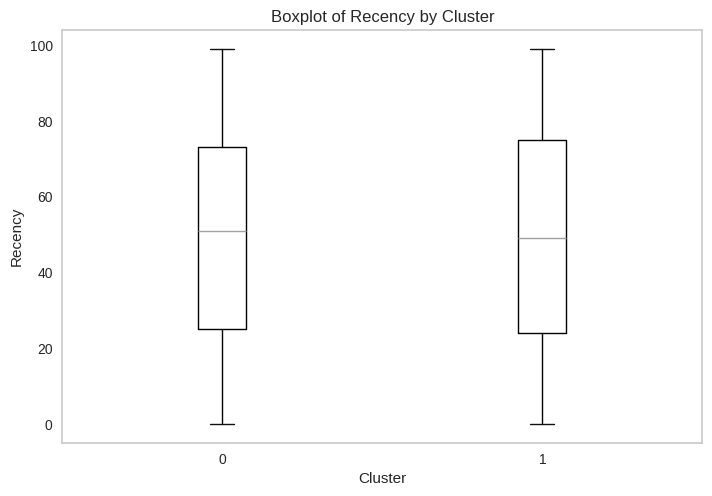

<Figure size 500x400 with 0 Axes>

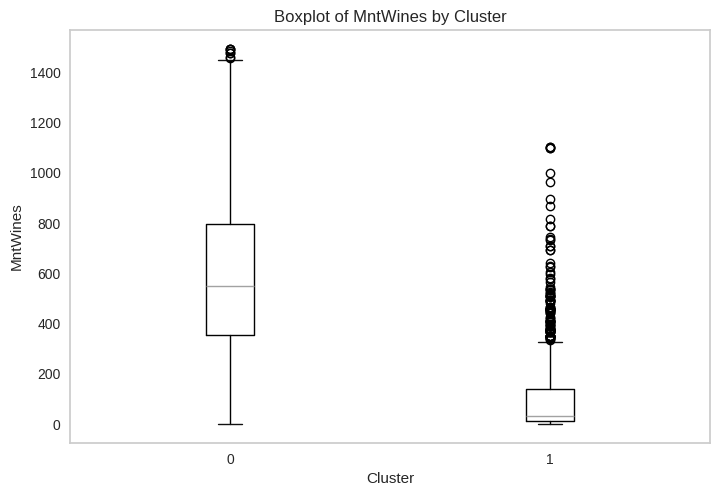

<Figure size 500x400 with 0 Axes>

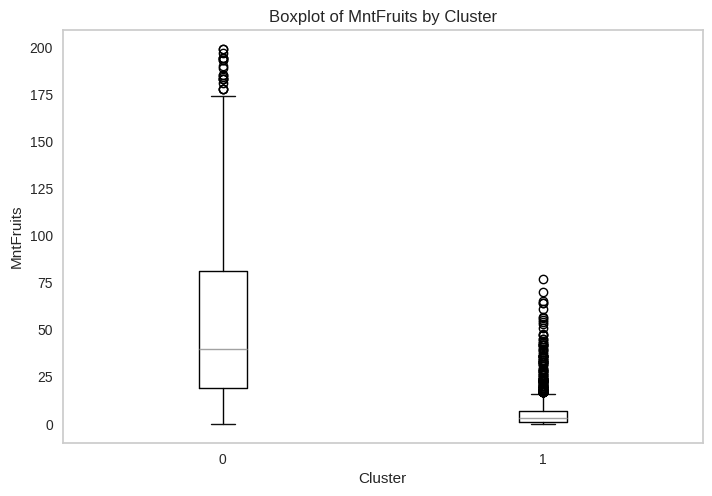

<Figure size 500x400 with 0 Axes>

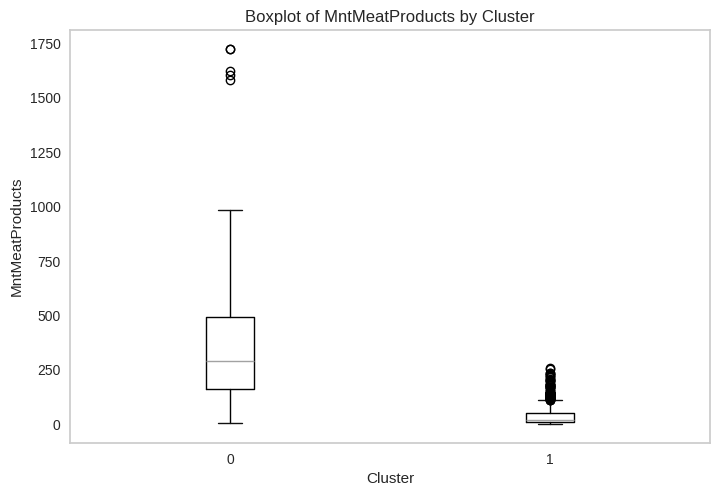

<Figure size 500x400 with 0 Axes>

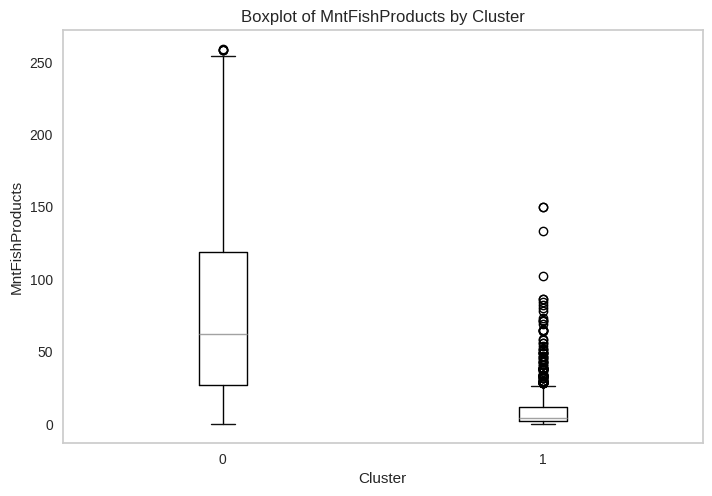

<Figure size 500x400 with 0 Axes>

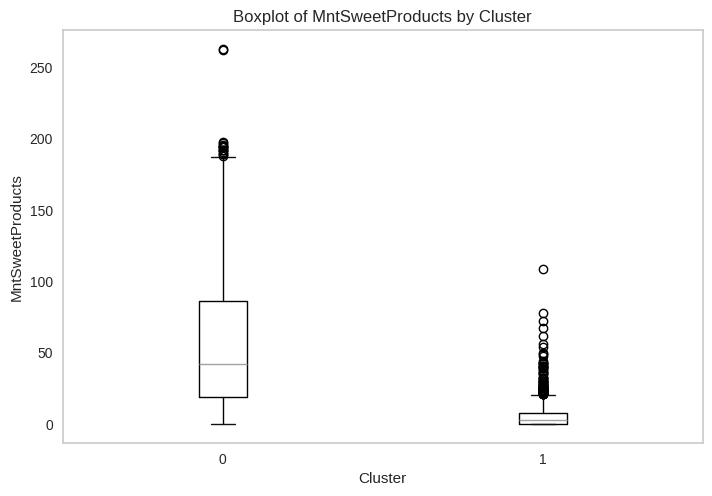

<Figure size 500x400 with 0 Axes>

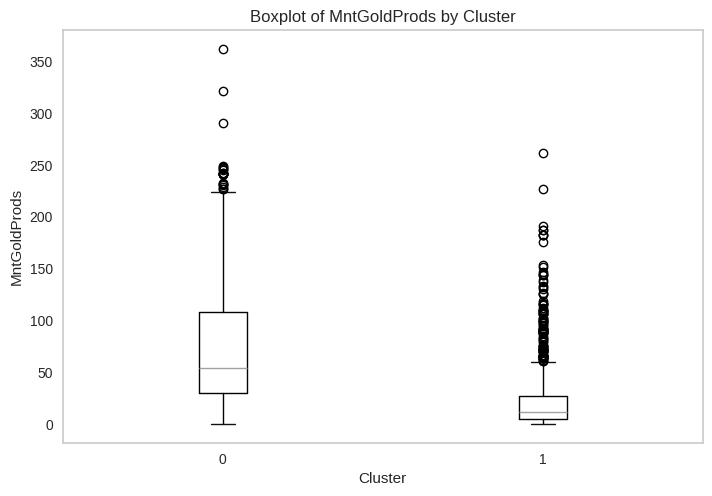

<Figure size 500x400 with 0 Axes>

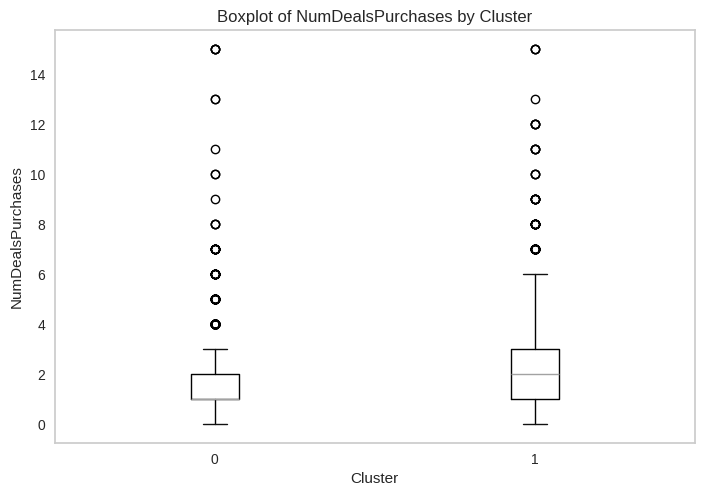

<Figure size 500x400 with 0 Axes>

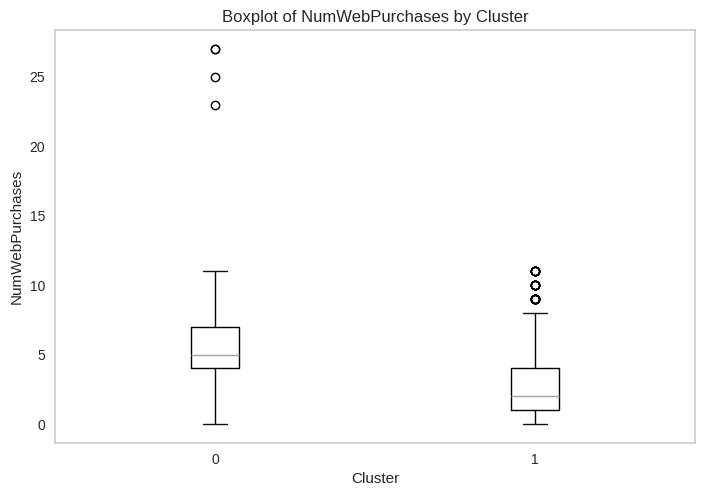

<Figure size 500x400 with 0 Axes>

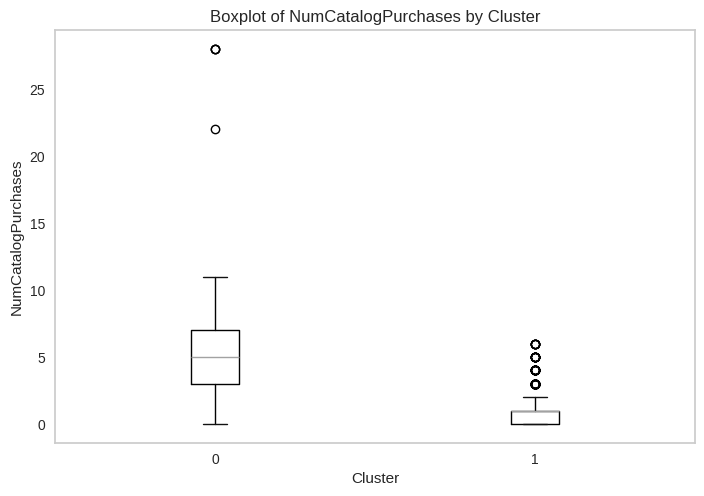

<Figure size 500x400 with 0 Axes>

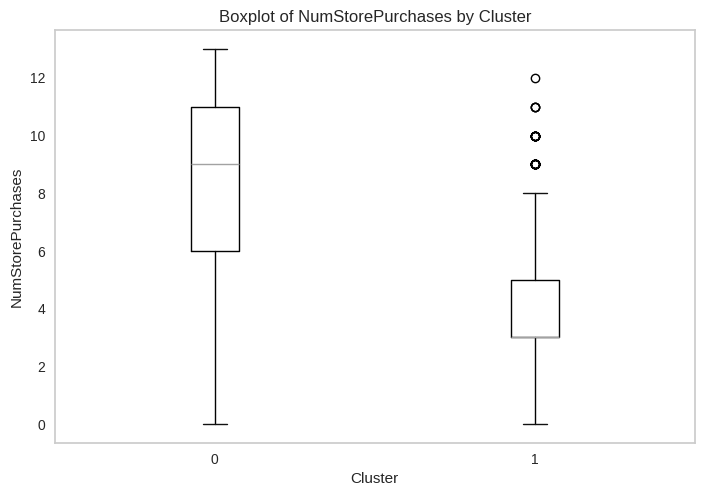

<Figure size 500x400 with 0 Axes>

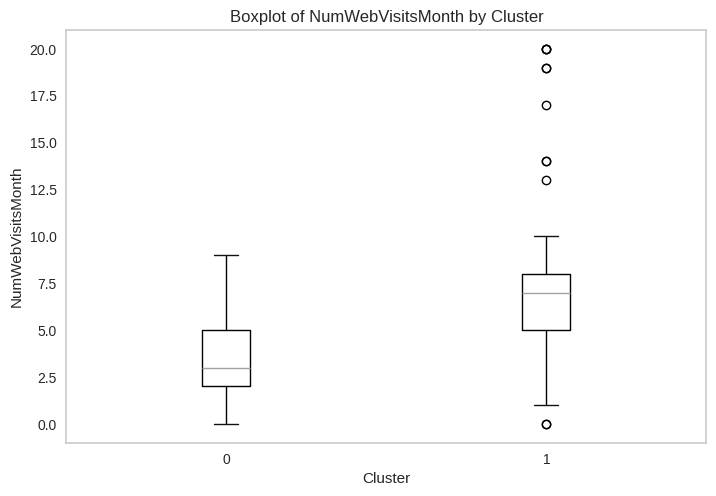

<Figure size 500x400 with 0 Axes>

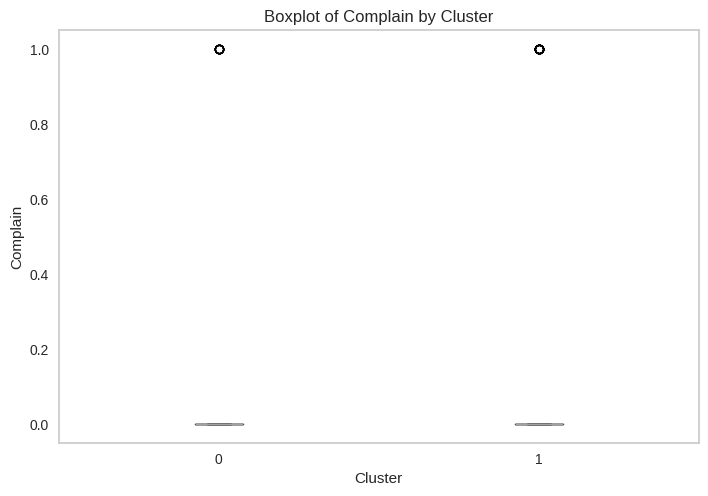

<Figure size 500x400 with 0 Axes>

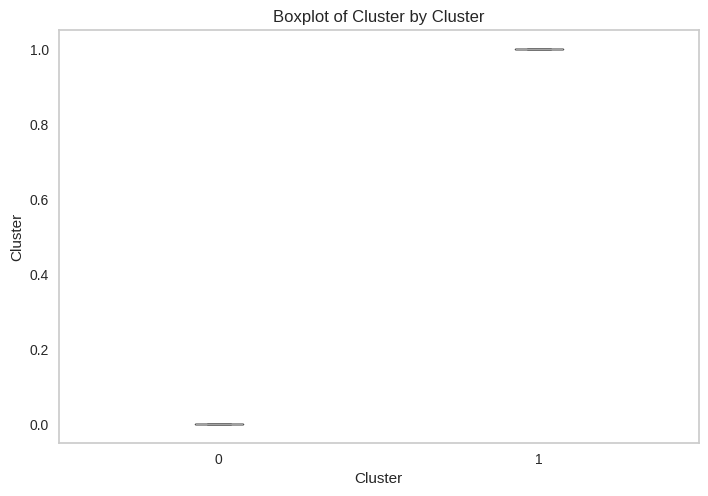

In [35]:
# assign cluster labels to a new column in the dataset
data['Cluster'] = kmeans_final.labels_

# Loop through numerical columns and plot boxplots by cluster

for col in data:
    plt.figure(figsize=(5,4))
    data.boxplot(column=col, by='Cluster', grid=False)
    plt.title(f'Boxplot of {col} by Cluster')
    plt.suptitle("")  # Remove the default suptitle
    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.show()

##### **Observations:**

*   In the Year_Birth visual, cluster 0 has slightly older customers with median around 1970 and cluster 1 has slightly younger customers with median above 1970.

*   In the Income visual, customers in cluster 0 have more income witha higher median than the customers in cluster 1.

*   In the Kidhome visual, customers in cluster 0 mostly have no kid and customers in cluster 1 have a wider distribution which includes households with 0, 1 and 2 kids.

*   In the Teenhome visual, the two clusters have similar distribution, most households have 0 or 1 teens and fewer households have 2 teens.

*   In the MntWines visual, customers in cluster 0 spend more on wines with a high median between 500 and 600 and a few customers spending more than 1400 while in cluster 1 customers spend little on wines with median less than 100 and a few outliers.

*   In the other spending varible visuals, customers in cluster 0 tend to spend higher with a higher median than customers in cluster 1.

*   In the numdealspurchases visuals, customers in cluster 0 tend to purchase lesser deals using discounts than customers in cluster 1 who purchased more deals with a discount with a median of 2 purchases.

*   Customers in cluster 0 made more catalog purchases compared to Cluster 1 with a median of 5 and an outlier above 25.

*   In the numstorepurchases visuals, Majority of the distribution of customers in cluster 0 make in store purchase with median around 9, showing that they prefer in store purchase. While cluster 1 make fewer in store purchase.

*   In the NumWebVisitsMonth visuals, Customers in  cluster 0 have fewer website visits with a median of 3 unlike customers in cluster 1 that have more website activities.










#### **Question 11**: Perform cluster profiling on the data using a barplot for the K-Means algorithm. Provide insights and key observations for each cluster based on the visual analysis.

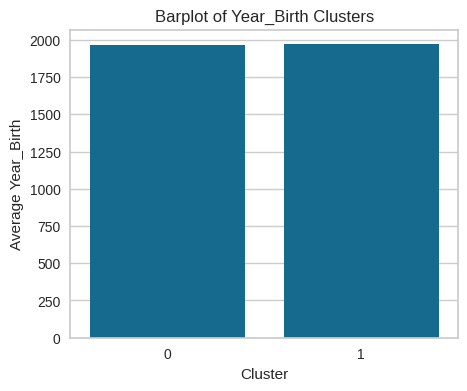

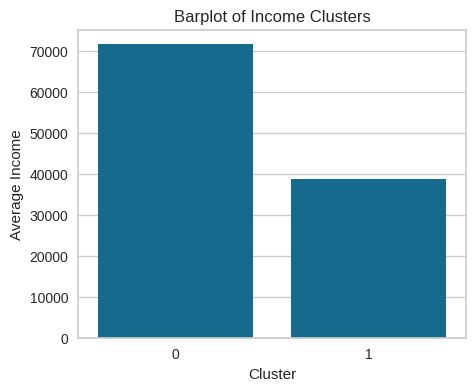

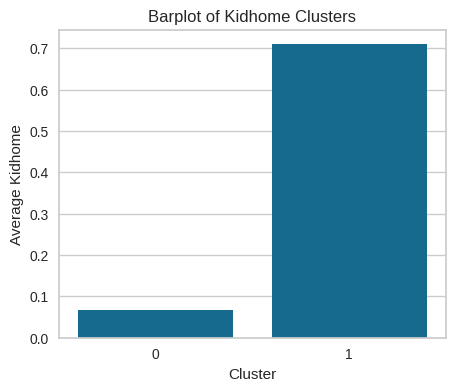

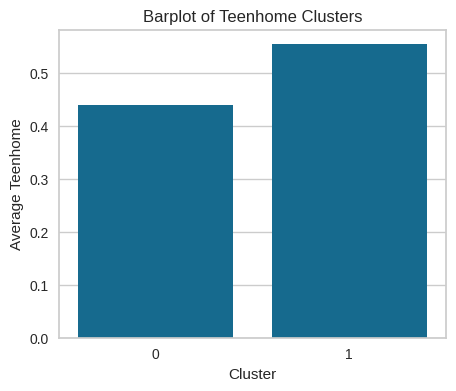

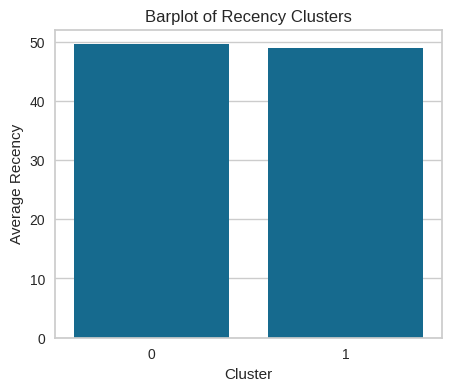

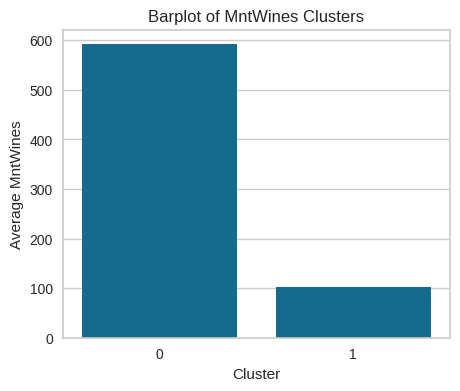

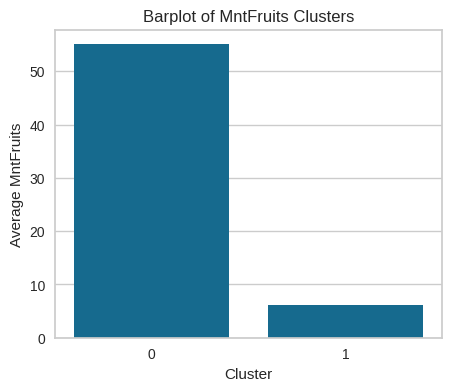

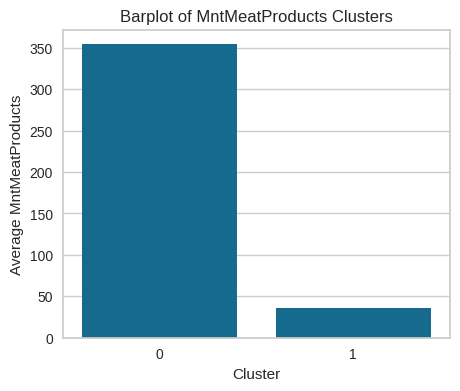

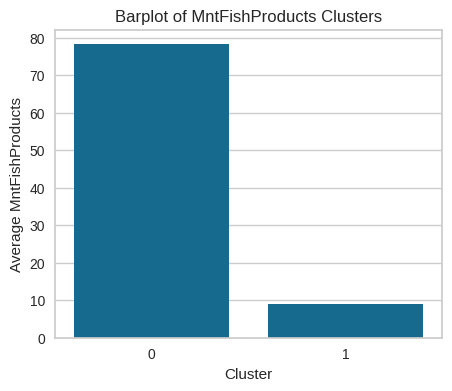

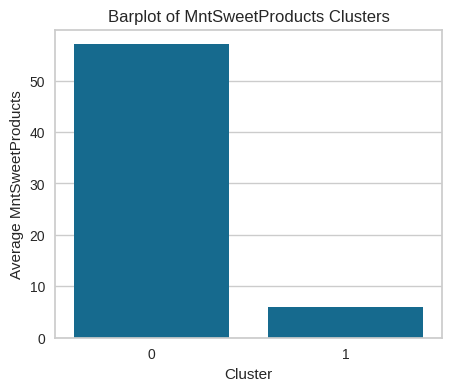

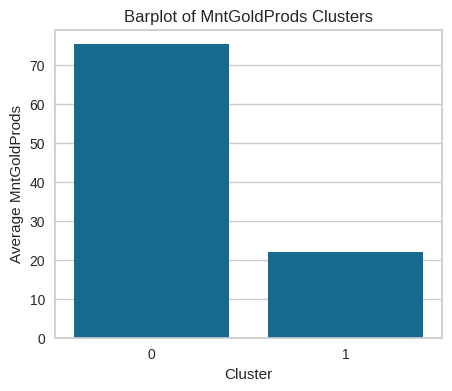

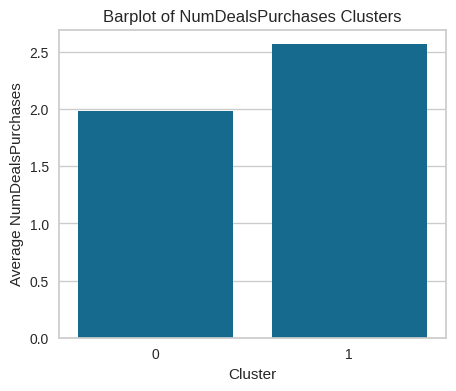

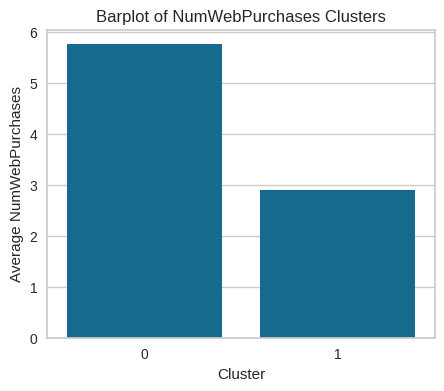

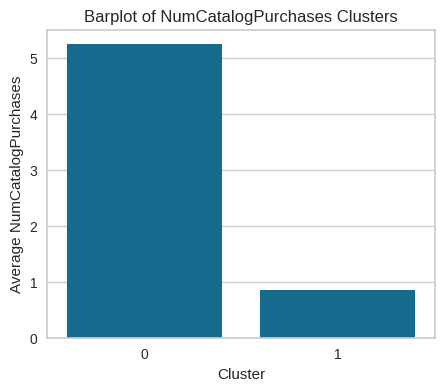

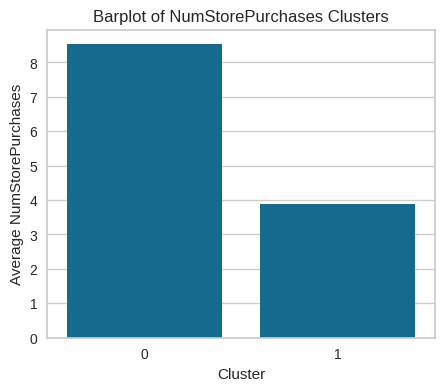

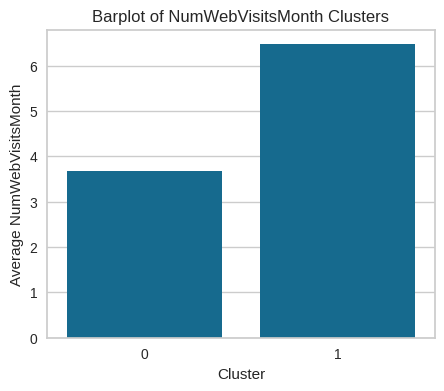

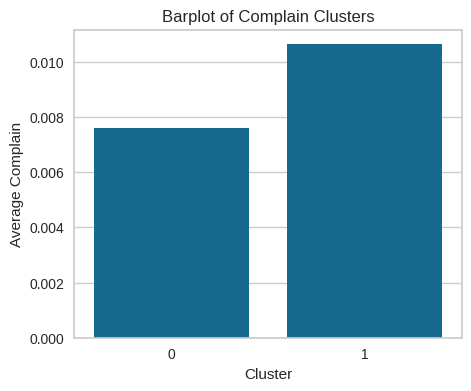

In [36]:
# Calculate mean values of each variable per cluster
cluster_avg = data.groupby('Cluster').mean()

# Plot barplots for each feature across clusters
for col in cluster_avg.columns:
    plt.figure(figsize=(5,4))
    sns.barplot(x=cluster_avg.index, y=cluster_avg[col])
    plt.title(f'Barplot of {col} Clusters')
    plt.xlabel("Cluster")
    plt.ylabel(f'Average {col}')
    plt.show()

##### **Observations:**

*   From the barplot of Year_Birth by Cluster, we see that both clusters have similar average year of birth, meaning that customers across both clusters are of similar age groups.

*   Cluster 0 has a much higher average income in the barplot of Income by Cluster while Cluster 1 represents lower-income customers.

*   Cluster 0 has a very low average number of children at home which means means Cluster 0 households are typically without children while Cluster 1 has a much higher average.

*   Cluster 0 has a very low average number of children at home which means means Cluster 0 households are typically without children while Cluster 1 has a much higher average and are more likely to have at least one child at home.

*   The average recency for the two clusters are very close, meaning both clusters have similar recentness of purchases.

*   Cluster 0 shows significantly higher average spending across all the spending variables; they spend heavily on wines and meat, followed by gold products and other categories. While cluster 1  displays much lower spending across all the spending variables especially luxury products like wines and gold products.

*   Average number of deal purchases in Cluster 1 is higher which aligns with their overall lower income and spending behavior while cluster 0 has a lesser average number of deal purchases which is around 2.0.

*   Cluster 0 shops more frequently through online channels which indicates stronger digital adoption while cluster 1 is less active in online shopping.


*   Cluster 0 also prefers in-store shopping unlike cluster 1

*   Cluster 0 has an average number of catalog purchases above 5 which indicates that customers in this group actively use catalog channels for shopping. Unlike Cluster 1 that is less interested in catalog purchases.

*   Cluster 0 visits the website less frequently while cluster 1 shows higher online browsing activity; However, earlier insights show they purchase less online, suggesting they are browsing for deals, comparing prices, or window shopping.












## **Business Recommedations**

#### **Question 12**: Based on the cluster insights, what business recommendations can be provided?

Based on the cluster insights:

We recommend the following for cluster 1 which is the customer segment or group that earns low income, and have more kids and teens at home and prefer browsing online searching for discounts to shop;

*   Promote affordable household and kid-friendly items.
*  Simplify online checkout, provide flexible payment options, and introduce a loyalty points program to reward and encourage repeat purchases among low-spending customers.
*   Leverage their frequent web visits with targeted online campaigns.
*  Stock higher volumes of discounted/family products in stores.
*  Family-focused campaign: recipe booklets, back-to-school offer eg kids’ back pack.




For customers in cluster 0 who earn high income with little or no kids and teens in the home and fewer web visits but spend heavily; we recommend that;

*   Provide Personalised assistance across all channels.
*   Create an instore experience by improving the store layout with premium zones and experience area such as wine tasting corners.
*   Exceptional customer engagement approach,surprise-and-delight tactics (anniversary deals)
*   Upselling and cross-selling campaigns.
*   Customized E-mails/catalogues with exclusive purchase high-end product combinations.







